# Imports + Style

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback.
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

from src.utils.paths import MODEL_OUTPUTS_ROOT as LEGACY_MODEL_OUTPUTS_ROOT, OUTPUTS
from src.data.density_dice import load_dice_metrics, load_density_tertiles
from src.utils.constants import (
    COLOR_MAP,
    F1_NAME_MAP,
    FIG_SIZES,
)

from cnt_project.visualizations.experiments.paper_figures.density_dice_plots import (
    plot_density_dice,
)

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

_output_root_candidates = [
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
    PROJECT_ROOT / "global_outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "Global_Outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "global_outputs" / "runs",
]
MODEL_OUTPUTS_ROOT = next(
    (p for p in _output_root_candidates if p.exists()),
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
)
print(f"Using MODEL_OUTPUTS_ROOT: {MODEL_OUTPUTS_ROOT}")

Using MODEL_OUTPUTS_ROOT: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs


# Load DICE + Assign Density Groups

### curently the runs in the cell are the old runs used for the previous version of the paper

In [13]:
metric_file = "per_image_threshold_metrics_calc_dsb_map.csv"
model_names = ["fluo_new_edt", "detectron2_trial_1", "wormswin", "nano1D"]

# Step 1: Load DICE
dice_df = load_dice_metrics(
    model_names,
    MODEL_OUTPUTS_ROOT,
    metric_file,
 )

# Step 2: Map models to readable names
dice_df["experiment"] = dice_df["experiment"].map(lambda x: F1_NAME_MAP.get(x, x))

# Step 3: Load density tertile classification
_density_csv_candidates = [
    PROJECT_ROOT / "data" / "annotations_uniques" / "test" / "metadata" / "density_classified_filenames.csv",
    PROJECT_ROOT / "data" / "annotations_uniques" / "metadata" / "Density_classified_filenames.csv",
    PROJECT_ROOT / "global_outputs" / "misc" / "legacy files inside global outputs" / "Density_classified_filenames.csv",
    MODEL_OUTPUTS_ROOT.parent / "Density_classified_filenames.csv",
]
density_csv = next((p for p in _density_csv_candidates if p.exists()), _density_csv_candidates[0])
print(f"Using density_csv: {density_csv}")
density_map = load_density_tertiles(density_csv)

def _normalize_image_stem(name: str) -> str:
    text = str(name).strip().lower()
    for ext in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
        if text.endswith(ext):
            text = text[:-len(ext)]
            break
    return text

density_map_norm = {_normalize_image_stem(k): v for k, v in density_map.items()}

# Add density (robust filename normalization avoids accidental row drops)
dice_df["filename"] = dice_df["image_id"].map(_normalize_image_stem)
dice_df["density"] = dice_df["filename"].map(density_map_norm)

# Drop missing density info + Nano1D
dice_df = dice_df.dropna(subset=["density"])
dice_df = dice_df[dice_df["experiment"] != "Nano1D"]

dice_df.head()


Using density_csv: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\annotations_uniques\test\metadata\density_classified_filenames.csv


,image_id,avg_dice,experiment,filename,density
0,1293-22_3_2_20230306222551,0.477829,NanoVision,1293-22_3_2_20230306222551,High
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,0.572796,NanoVision,400-1093-w11-c1p1-befo3-10sp-15flow_left,High
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,0.536584,NanoVision,400-1093-w11-c1p2-befo3-20sp-15flow_left,High
3,400-1093-w13-c1-p1-10sp-15flow_left,0.597819,NanoVision,400-1093-w13-c1-p1-10sp-15flow_left,High
4,400-1093-w16-c-1-p1-10sp-15flow_left,0.573775,NanoVision,400-1093-w16-c-1-p1-10sp-15flow_left,High


In [3]:
dice_df['experiment'].value_counts()

experiment
NanoVision    30
MaskRCNN      30
WormSwin      28
Name: count, dtype: int64

Old-runs sample-count comparison (before fix vs after fix):


,experiment,density,n_before_fix,n_after_fix,delta
0,MaskRCNN,High,9,9,0
1,MaskRCNN,Low,6,11,5
2,MaskRCNN,Mid,2,10,8
3,NanoVision,High,9,9,0
4,NanoVision,Low,6,11,5
5,NanoVision,Mid,2,10,8
6,WormSwin,High,9,9,0
7,WormSwin,Low,6,10,4
8,WormSwin,Mid,2,9,7


c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\density_dice_plots.py:168: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


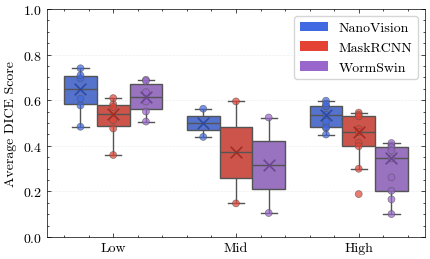

Saved BEFORE-fix old-runs figure to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\density_dice_old_runs_before_fix.svg


c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\density_dice_plots.py:168: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


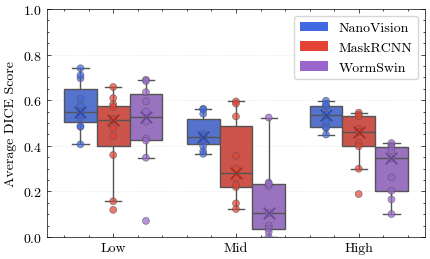

Saved AFTER-fix old-runs figure to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\density_dice_old_runs_after_fix.svg


In [14]:
# Diagnostic: recreate old fragile mapping (before filename-normalization fix)
dice_df_before_fix = load_dice_metrics(
    model_names,
    MODEL_OUTPUTS_ROOT,
    metric_file,
)
dice_df_before_fix["experiment"] = dice_df_before_fix["experiment"].map(lambda x: F1_NAME_MAP.get(x, x))

# Fragile behavior used previously
dice_df_before_fix["filename"] = dice_df_before_fix["image_id"].astype(str).str.split(".").str[0]
dice_df_before_fix["density"] = dice_df_before_fix["filename"].map(density_map)
dice_df_before_fix = dice_df_before_fix.dropna(subset=["density"])
dice_df_before_fix = dice_df_before_fix[dice_df_before_fix["experiment"] != "Nano1D"]

before_counts = (
    dice_df_before_fix.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .size()
    .rename(columns={"size": "n_before_fix"})
)
after_counts = (
    dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .size()
    .rename(columns={"size": "n_after_fix"})
)
count_delta = (
    before_counts.merge(after_counts, on=["experiment", "density"], how="outer")
    .fillna(0)
    .assign(
        n_before_fix=lambda x: x["n_before_fix"].astype(int),
        n_after_fix=lambda x: x["n_after_fix"].astype(int),
    )
    .assign(delta=lambda x: x["n_after_fix"] - x["n_before_fix"])
    .sort_values(["experiment", "density"])
)
print("Old-runs sample-count comparison (before fix vs after fix):")
display(count_delta)

legend_name_map_local = {
    "NanoVision": "NanoVision",
    "MaskRCNN": "MaskRCNN",
    "WormSwin": "WormSwin",
}
plot_colors_local = {
    "NanoVision": COLOR_MAP["NanoVision"],
    "MaskRCNN": COLOR_MAP["MaskRCNN"],
    "WormSwin": COLOR_MAP["WormSwin"],
}
marker_visual_nudge_local = {
    "NanoVision": 0.0,
    "MaskRCNN": 0.0,
    "WormSwin": 0.0,
}

before_fix_save_path = OUTPUTS["density"] / "density_dice_old_runs_before_fix.svg"
plot_density_dice(
    df=dice_df_before_fix,
    color_map=plot_colors_local,
    legend_name_map=legend_name_map_local,
    figsize=FIG_SIZES["density_dice_fig"],
    marker_visual_nudge=marker_visual_nudge_local,
    save_path=before_fix_save_path,
)
print("Saved BEFORE-fix old-runs figure to:", before_fix_save_path)

after_fix_save_path = OUTPUTS["density"] / "density_dice_old_runs_after_fix.svg"
plot_density_dice(
    df=dice_df,
    color_map=plot_colors_local,
    legend_name_map=legend_name_map_local,
    figsize=FIG_SIZES["density_dice_fig"],
    marker_visual_nudge=marker_visual_nudge_local,
    save_path=after_fix_save_path,
)
print("Saved AFTER-fix old-runs figure to:", after_fix_save_path)

In [12]:
# Diagnostic: show why fragile vs robust may differ by density CSV source
_diagnostic_density_csvs = [
    PROJECT_ROOT / "global_outputs" / "misc" / "legacy files inside global outputs" / "Density_classified_filenames.csv",
    PROJECT_ROOT / "data" / "annotations_uniques" / "test" / "metadata" / "density_classified_filenames.csv",
]

def _count_by_mode_for_csv(csv_path: Path) -> pd.DataFrame:
    dmap = load_density_tertiles(csv_path)
    dmap_norm = {_normalize_image_stem(k): v for k, v in dmap.items()}

    base = load_dice_metrics(model_names, MODEL_OUTPUTS_ROOT, metric_file).copy()
    base["experiment"] = base["experiment"].map(lambda x: F1_NAME_MAP.get(x, x))
    base = base[base["experiment"] != "Nano1D"].copy()

    fragile = base.copy()
    fragile["filename"] = fragile["image_id"].astype(str).str.split(".").str[0]
    fragile["density"] = fragile["filename"].map(dmap)
    fragile = fragile.dropna(subset=["density"])

    robust = base.copy()
    robust["filename"] = robust["image_id"].map(_normalize_image_stem)
    robust["density"] = robust["filename"].map(dmap_norm)
    robust = robust.dropna(subset=["density"])

    c1 = (
        fragile.groupby(["experiment", "density"], as_index=False)["avg_dice"]
        .size()
        .rename(columns={"size": "fragile_n"})
    )
    c2 = (
        robust.groupby(["experiment", "density"], as_index=False)["avg_dice"]
        .size()
        .rename(columns={"size": "robust_n"})
    )
    out = c1.merge(c2, on=["experiment", "density"], how="outer").fillna(0)
    out["fragile_n"] = out["fragile_n"].astype(int)
    out["robust_n"] = out["robust_n"].astype(int)
    out["delta"] = out["robust_n"] - out["fragile_n"]
    out["density_csv"] = str(csv_path)
    return out

diagnostic_rows = []
for _csv in _diagnostic_density_csvs:
    if _csv.exists():
        diagnostic_rows.append(_count_by_mode_for_csv(_csv))

if diagnostic_rows:
    source_effect = pd.concat(diagnostic_rows, ignore_index=True)
    source_effect = source_effect[["density_csv", "experiment", "density", "fragile_n", "robust_n", "delta"]]
    display(source_effect.sort_values(["density_csv", "experiment", "density"]))
else:
    print("No diagnostic density CSV files found")

,density_csv,experiment,density,fragile_n,robust_n,delta
9,c:\Users\abd93000\PycharmProjects\cnt_project_...,MaskRCNN,High,9,9,0
10,c:\Users\abd93000\PycharmProjects\cnt_project_...,MaskRCNN,Low,6,11,5
11,c:\Users\abd93000\PycharmProjects\cnt_project_...,MaskRCNN,Mid,2,10,8
12,c:\Users\abd93000\PycharmProjects\cnt_project_...,NanoVision,High,9,9,0
13,c:\Users\abd93000\PycharmProjects\cnt_project_...,NanoVision,Low,6,11,5
14,c:\Users\abd93000\PycharmProjects\cnt_project_...,NanoVision,Mid,2,10,8
15,c:\Users\abd93000\PycharmProjects\cnt_project_...,WormSwin,High,9,9,0
16,c:\Users\abd93000\PycharmProjects\cnt_project_...,WormSwin,Low,6,10,4
17,c:\Users\abd93000\PycharmProjects\cnt_project_...,WormSwin,Mid,2,9,7
0,c:\Users\abd93000\PycharmProjects\cnt_project_...,MaskRCNN,High,9,9,0


# Plot the Box/Strip + Medians

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\density_dice_plots.py:168: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


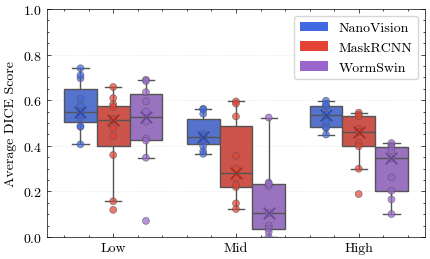

Saved to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\density_dice.svg


In [15]:
save_path = OUTPUTS["density"] / "density_dice.svg"

legend_name_map = {
    "NanoVision": "NanoVision",
    "MaskRCNN": "MaskRCNN",
    "WormSwin": "WormSwin"
}

# Use only the models we have colors for
plot_colors = {
    "NanoVision": COLOR_MAP["NanoVision"],
    "MaskRCNN": COLOR_MAP["MaskRCNN"],
    "WormSwin": COLOR_MAP["WormSwin"]
}

# Keep neutral nudges; placement now comes from corrected dodge geometry.
marker_visual_nudge = {
    "NanoVision": 0.0,
    "MaskRCNN": 0.0,
    "WormSwin": 0.0,
}

plot_density_dice(
    df=dice_df,
    color_map=plot_colors,
    legend_name_map=legend_name_map,
    figsize=FIG_SIZES["density_dice_fig"],
    marker_visual_nudge=marker_visual_nudge,
    save_path=save_path
)

print("Saved to:", save_path)


# New Runs Density-DICE (Summary-Compatible Block)

This block keeps the original section unchanged and builds a second figure using the newer runs.
It intentionally uses the same source and split as `full_dataset_run_metrics_table.ipynb`:
- `eval/dsb/density_eval__gt-approx-none__pred-poly/ap_dice_results_poly_<DENSITY>.csv`
- `mean_dice` values per image (then plotted as distributions by density).

In [5]:
from cnt_project.io.paths import ProjectPaths

P = ProjectPaths.from_here(PROJECT_ROOT / "src" / "cnt_project" / "io" / "paths.py")

NEW_RUNS = [
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004",
    "detectron2_trial_1_LB_legacy_recheck",
    "wormswin_20260610",
]
NEW_RUN_NAME_MAP = {
    "fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004": "NanoVision",
    "detectron2_trial_1_LB_legacy_recheck": "MaskRCNN",
    "wormswin_20260610": "WormSwin",
}

density_eval_dirname = "density_eval__gt-approx-none__pred-poly"
density_groups = [
    ("LOW_DENSITY", "Low"),
    ("MID_DENSITY", "Mid"),
    ("HIGH_DENSITY", "High"),
]

rows = []
missing_files = []

for run_name in NEW_RUNS:
    model_label = NEW_RUN_NAME_MAP.get(run_name, run_name)
    for density_key, density_label in density_groups:
        metrics_path = (
            P.runs_root
            / run_name
            / "eval"
            / "dsb"
            / density_eval_dirname
            / f"ap_dice_results_poly_{density_key}.csv"
        )
        if not metrics_path.exists():
            missing_files.append(str(metrics_path))
            continue

        part = pd.read_csv(metrics_path)
        if "mean_dice" not in part.columns or "image_id" not in part.columns:
            continue

        part = part[["image_id", "mean_dice"]].copy()
        part = part.rename(columns={"mean_dice": "avg_dice"})
        part["experiment"] = model_label
        part["density"] = density_label
        rows.append(part)

if not rows:
    raise ValueError("No valid new-run density_eval DICE files found")

new_dice_df = pd.concat(rows, ignore_index=True)

if missing_files:
    print("Missing files:")
    for path in missing_files:
        print(path)

new_dice_mean_summary = (
    new_dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .mean()
    .pivot(index="experiment", columns="density", values="avg_dice")
    .reindex(columns=["Low", "Mid", "High"])
    .round(4)
)
print("Summary-compatible mean object DICE (new runs):")
display(new_dice_mean_summary)

new_dice_df.head()

Summary-compatible mean object DICE (new runs):


density,Low,Mid,High
experiment,,,
MaskRCNN,0.5054,0.3118,0.4571
NanoVision,0.6084,0.5192,0.5589
WormSwin,0.4408,0.2282,0.3204


,image_id,avg_dice,experiment,density
0,7,0.5725,NanoVision,Low
1,8,0.7019,NanoVision,Low
2,9,0.7169,NanoVision,Low
3,10,0.7834,NanoVision,Low
4,16,0.5867,NanoVision,Low


c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\density_dice_plots.py:168: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


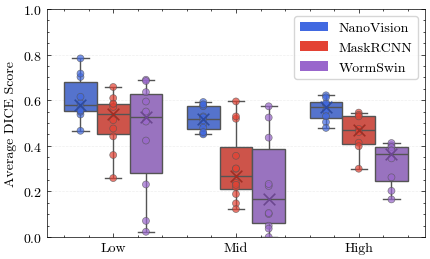

Saved new-runs density DICE figure to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\density_dice_new_runs.svg


In [6]:
new_save_path = OUTPUTS["density"] / "density_dice_new_runs.svg"

plot_density_dice(
    df=new_dice_df,
    color_map=plot_colors,
    legend_name_map=legend_name_map,
    figsize=FIG_SIZES["density_dice_fig"],
    marker_stat="median",
    marker_visual_nudge=marker_visual_nudge,
    save_path=new_save_path,
)

print("Saved new-runs density DICE figure to:", new_save_path)

## Important note on density grouping source (why distributions differ)

The old-runs and new-runs sections in this notebook do **not** currently use the same density classification source.

- **Old runs (`dice_df`)**: density is assigned by mapping image names using `density_classified_filenames.csv`.
- **New runs (`new_dice_df`)**: density groups are taken from DSB density-eval outputs (`ap_dice_results_poly_<DENSITY>.csv`), which are produced by the DSB runner using `description.txt` group membership.

Because these are two different source-of-truth files/workflows, the per-density image counts can differ (for example, `old_n_images` vs `new_n_images`).

### Action needed (single source of truth)

This should be unified: both old and new comparisons should use the **same density classification source**.

Recommended fix direction:
1. Pick one canonical density source (preferably the DSB runner path used for new runs).
2. Rebuild legacy/old-run density grouping from that same canonical source.
3. Re-run this notebook so old/new density distributions are directly comparable without source-driven bias.

In [8]:
old_summary_median = (
    dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .median()
    .rename(columns={"avg_dice": "old_median_dice"})
)

old_summary_mean = (
    dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .mean()
    .rename(columns={"avg_dice": "old_mean_dice"})
)

old_counts = (
    dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .size()
    .rename(columns={"size": "old_n_images"})
)

new_summary_median = (
    new_dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .median()
    .rename(columns={"avg_dice": "new_median_dice"})
)

new_summary_mean = (
    new_dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .mean()
    .rename(columns={"avg_dice": "new_mean_dice_summary_compatible"})
)

new_counts = (
    new_dice_df.groupby(["experiment", "density"], as_index=False)["avg_dice"]
    .size()
    .rename(columns={"size": "new_n_images"})
)

comparison_summary = (
    old_summary_median
    .merge(old_summary_mean, on=["experiment", "density"], how="outer")
    .merge(old_counts, on=["experiment", "density"], how="outer")
    .merge(new_summary_median, on=["experiment", "density"], how="outer")
    .merge(new_summary_mean, on=["experiment", "density"], how="outer")
    .merge(new_counts, on=["experiment", "density"], how="outer")
    .sort_values(["experiment", "density"])
)
comparison_summary

,experiment,density,old_median_dice,old_mean_dice,old_n_images,new_median_dice,new_mean_dice_summary_compatible,new_n_images
0,MaskRCNN,High,0.460482,0.427258,9,0.46730,0.457125,8
1,MaskRCNN,Low,0.512716,0.454984,11,0.54160,0.505360,10
2,MaskRCNN,Mid,0.279838,0.334256,10,0.26830,0.311800,12
3,NanoVision,High,0.536584,0.531226,9,0.56805,0.558863,8
4,NanoVision,Low,0.547129,0.573736,11,0.57960,0.608420,10
5,NanoVision,Mid,0.440719,0.456393,10,0.51845,0.519242,12
6,WormSwin,High,0.345006,0.295984,9,0.36225,0.320362,8
7,WormSwin,Low,0.528317,0.493375,10,0.52830,0.440770,10
8,WormSwin,Mid,0.105439,0.159450,9,0.16460,0.228230,10
